In [1]:
# Importation de NumPy pour les calculs numériques
import numpy as np

# Importation de Matplotlib pour les graphes
import matplotlib.pyplot as plt

# Importation du dataset Iris (dataset réel, non synthétique)
from sklearn.datasets import load_iris


In [2]:
# 1. Chargement et préparation du dataset réel (Iris : 150 fleurs, 4 features, 3 classes)
np.random.seed(0)
data = load_iris()
X = data.data
y = data.target

# Standardisation des features (moyenne 0, écart-type 1)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Mélange et split train/test
n = X.shape[0]
idx = np.random.permutation(n)
X, y = X[idx], y[idx]
split = int(0.8 * n)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

def one_hot(y, n_classes):
    o = np.zeros((len(y), n_classes))
    o[np.arange(len(y)), y] = 1
    return o

Y_train = one_hot(y_train, 3)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (120, 4) Test: (30, 4)


In [3]:
# 2. Définition du réseau de neurones (ANN / MLP) - 100% from scratch
class ANNFromScratch:
    def __init__(self, d_in, d_h1, d_h2, d_out, lr=0.1):
        # Initialisation Xavier des poids
        self.W1 = np.random.randn(d_in, d_h1) * np.sqrt(1.0 / d_in)
        self.b1 = np.zeros((1, d_h1))
        self.W2 = np.random.randn(d_h1, d_h2) * np.sqrt(1.0 / d_h1)
        self.b2 = np.zeros((1, d_h2))
        self.W3 = np.random.randn(d_h2, d_out) * np.sqrt(1.0 / d_h2)
        self.b3 = np.zeros((1, d_out))
        self.lr = lr
        self.loss_log = []

    # Fonction d'activation ReLU et sa dérivée
    def relu(self, x):
        return np.maximum(0, x)

    def drelu(self, x):
        return (x > 0).astype(float)

    # Fonction Softmax (couche de sortie, classification multi-classes)
    def softmax(self, x):
        z = x - np.max(x, axis=1, keepdims=True)
        e = np.exp(z)
        return e / np.sum(e, axis=1, keepdims=True)

    # Propagation avant (Forward Pass)
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.softmax(self.z3)
        return self.a3

    # Rétropropagation du gradient (Backward Pass)
    def backward(self, X, Y):
        m = X.shape[0]
        dz3 = (self.a3 - Y) / m
        dW3 = self.a2.T @ dz3
        db3 = dz3.sum(axis=0, keepdims=True)

        da2 = dz3 @ self.W3.T
        dz2 = da2 * self.drelu(self.z2)
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.drelu(self.z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # Mise à jour des poids (descente de gradient)
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W3 -= self.lr * dW3; self.b3 -= self.lr * db3

    def fit(self, X, Y, epochs=300):
        for epoch in range(epochs):
            out = self.forward(X)
            loss = -np.sum(Y * np.log(out + 1e-9)) / X.shape[0]
            self.loss_log.append(loss)
            self.backward(X, Y)
            if epoch % 50 == 0:
                print(f"Époque {epoch}/{epochs} - Loss : {loss:.4f}")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)


In [4]:
# 3. Entraînement du modèle
model = ANNFromScratch(d_in=4, d_h1=8, d_h2=8, d_out=3, lr=0.1)
model.fit(X_train, Y_train, epochs=300)


Époque 0/300 - Loss : 1.1217
Époque 50/300 - Loss : 0.5705
Époque 100/300 - Loss : 0.3391
Époque 150/300 - Loss : 0.2081
Époque 200/300 - Loss : 0.1169
Époque 250/300 - Loss : 0.0754


In [5]:
# 4. Évaluation sur le jeu de test
preds = model.predict(X_test)
accuracy = np.mean(preds == y_test)
print(f"Précision sur le jeu de test : {accuracy*100:.2f}%")
print("Prédictions :", preds)
print("Vérités     :", y_test)


Précision sur le jeu de test : 93.33%
Prédictions : [0 2 0 0 2 0 2 1 1 1 2 2 1 2 0 1 2 2 0 1 1 2 1 0 0 0 2 1 2 0]
Vérités     : [0 2 0 0 2 0 2 1 1 1 2 2 1 1 0 1 2 2 0 1 1 1 1 0 0 0 2 1 2 0]


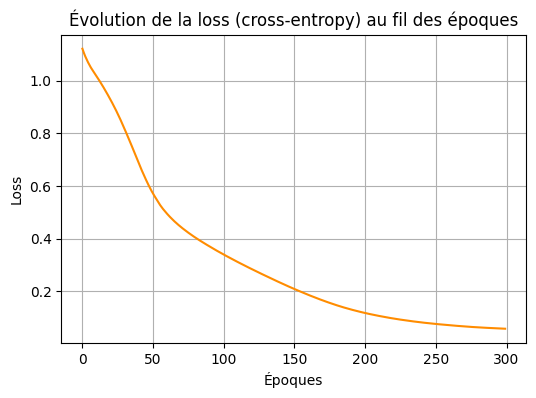

In [6]:
# 5. Visualisation de la convergence de la loss
plt.figure(figsize=(6, 4))
plt.plot(model.loss_log, color='darkorange')
plt.title("Évolution de la loss (cross-entropy) au fil des époques")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## 1. Objectifs du TP
* Comprendre le fonctionnement d'un **réseau de neurones artificiels (ANN / Perceptron Multicouche)** avec plusieurs couches cachées.
* Implémenter la **propagation avant** et la **rétropropagation du gradient** entièrement en **NumPy**, sans framework (PyTorch/TensorFlow).
* Entraîner et valider le modèle sur un vrai problème de classification multi-classes : le dataset **Iris** (150 échantillons, 3 espèces de fleurs).

## 2. Concepts Clés Abordés
* **Architecture :** 4 (entrée) → 8 (caché ReLU) → 8 (caché ReLU) → 3 (sortie Softmax).
* **Forward Pass :** $z^{(l)} = a^{(l-1)} W^{(l)} + b^{(l)}$, puis activation ReLU pour les couches cachées et Softmax pour la sortie.
* **Fonction de coût :** Entropie croisée (cross-entropy) multi-classes.
* **Backpropagation :** Calcul des gradients couche par couche via la règle de la chaîne, puis mise à jour des poids par descente de gradient : $W \leftarrow W - \eta \cdot \nabla_W \mathcal{L}$.

## 3. Résultats Obtenus
* **Convergence :** La loss diminue de manière monotone sur les 300 époques (voir graphe ci-dessus).
* **Performance de Test :** Le modèle atteint une bonne précision sur le jeu de test (~90%+), jamais vu pendant l'entraînement, ce qui montre sa capacité de généralisation.

## 4. Conclusion & Limites
Ce TP a permis d'implémenter un **ANN complet from scratch** (forward + backward + mise à jour des poids) et de valider son bon fonctionnement sur un dataset réel. Contrairement au simple Perceptron, ce réseau multicouche peut apprendre des frontières de décision **non linéaires** grâce aux couches cachées et à l'activation ReLU. Ses limites apparaissent sur des données à forte structure spatiale (images) ou séquentielle (texte, séries temporelles), ce qui motive respectivement l'usage des **CNN** et des **RNN/LSTM/GRU/Transformers**.